# Análise Exploratória: A Síndrome da Sequência Longa
**Responsável:** Murilo José Passos Lima  
**Pergunta Central:** Franquias de cinema realmente exigem mais tempo do público do que filmes originais?

---

### 🎯 Motivação e Hipóteses
Existe uma percepção popular de que filmes de franquia e grandes sagas de Hollywood estão ficando cada vez mais longos e cansativos. Esta análise investiga essa hipótese a partir de três perspectivas:
1. **Mito vs. Realidade:** Filmes de franquia têm duração média estatisticamente maior do que filmes isolados (*Standalone*)?
2. **O Efeito Acumulativo:** À medida que uma saga progride (Filme 1, Filme 2, Filme 3+), a duração aumenta de forma contínua?
3. **Evolução Temporal:** Essa diferença de duração entre franquias e filmes isolados é um fenômeno recente ou sempre existiu?

## 1. Sub-hipótese 1: Mito vs. Realidade
**Pergunta:** Filmes de franquia têm duração média/mediana superior à de filmes isolados (*Standalone*)?

Nesta etapa, comparamos a distribuição da duração (`runtimeMinutes`) entre os dois grupos:
- **Filmes Isolados (`is_franchise == False`):** Produções sem sequências registradas.
- **Filmes de Franquia (`is_franchise == True`):** Produções vinculadas a coleções/sagas.

In [4]:
df = pd.read_csv("../data/df_tmdb.csv")

# Garantir que a coluna de duração é numérica e remover possíveis nulos
df_valid = df.dropna(subset=["runtimeMinutes", "is_franchise"]).copy()
df_valid["runtimeMinutes"] = df_valid["runtimeMinutes"].astype(int)

# Mapear rótulos mais claros para os gráficos
df_valid["tipo_filme"] = df_valid["is_franchise"].map({True: "Franquia", False: "Isolado"})

# Tabela comparativa de estatísticas descritivas
estatisticas = df_valid.groupby("tipo_filme")["runtimeMinutes"].agg(
    Quantidade="count",
    Média="mean",
    Mediana="median",
    Desvio_Padrão="std",
    Mínimo="min",
    Máximo="max"
).round(2)

display(estatisticas)

,Quantidade,Média,Mediana,Desvio_Padrão,Mínimo,Máximo
tipo_filme,,,,,,
Franquia,2605,109.33,104.0,22.73,51,321
Isolado,9850,110.69,106.0,22.97,45,566


In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# 1. Carregar e tratar a base
df = pd.read_csv('../data/df_tmdb.csv')
df_valid = df.dropna(subset=['runtimeMinutes', 'is_franchise']).copy()
df_valid['tipo_filme'] = df_valid['is_franchise'].map(
    {True: 'Franquia', False: 'Isolado'}
)

franquia = df_valid[df_valid['is_franchise'] == True]['runtimeMinutes']
isolado = df_valid[df_valid['is_franchise'] == False]['runtimeMinutes']

# 2. Teste Mann-Whitney U bi-caudal (two-sided)
u_stat, p_value = stats.mannwhitneyu(
    franquia, isolado, alternative='two-sided'
)

# 3. Effect size (rank-biserial correlation)
n1, n2 = len(franquia), len(isolado)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print(f'N Franquia: {n1} | N Isolado: {n2}')
print(
    f'Mediana Franquia: {franquia.median()} min | Mediana Isolado:'
    f' {isolado.median()} min'
)
print(f'Estatística U: {u_stat}')
print(f'p-valor (two-sided): {p_value:.7f}')
print(f'Effect size (rank-biserial r): {rank_biserial:.4f}')

if p_value < 0.05:
    if abs(rank_biserial) < 0.10:
        print("Conclusão: Há diferença estatisticamente significativa (devido ao alto N), mas o tamanho do efeito é insignificante/desprezível na prática (r < 0.10).")
    else:
        print("Conclusão: Há diferença estatisticamente e praticamente significativa.")
else:
    print("Conclusão: Não há diferença estatisticamente significativa entre os grupos.")

N Franquia: 2605 | N Isolado: 9850
Mediana Franquia: 104.0 min | Mediana Isolado: 106.0 min
Estatística U: 12137062.0
p-valor (two-sided): 0.0000219
Effect size (rank-biserial r): 0.0540
Conclusão: Há diferença estatisticamente significativa (devido ao alto N), mas o tamanho do efeito é insignificante/desprezível na prática (r < 0.10).


C:\Users\Danilo\AppData\Local\Temp\ipykernel_12308\3554707152.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


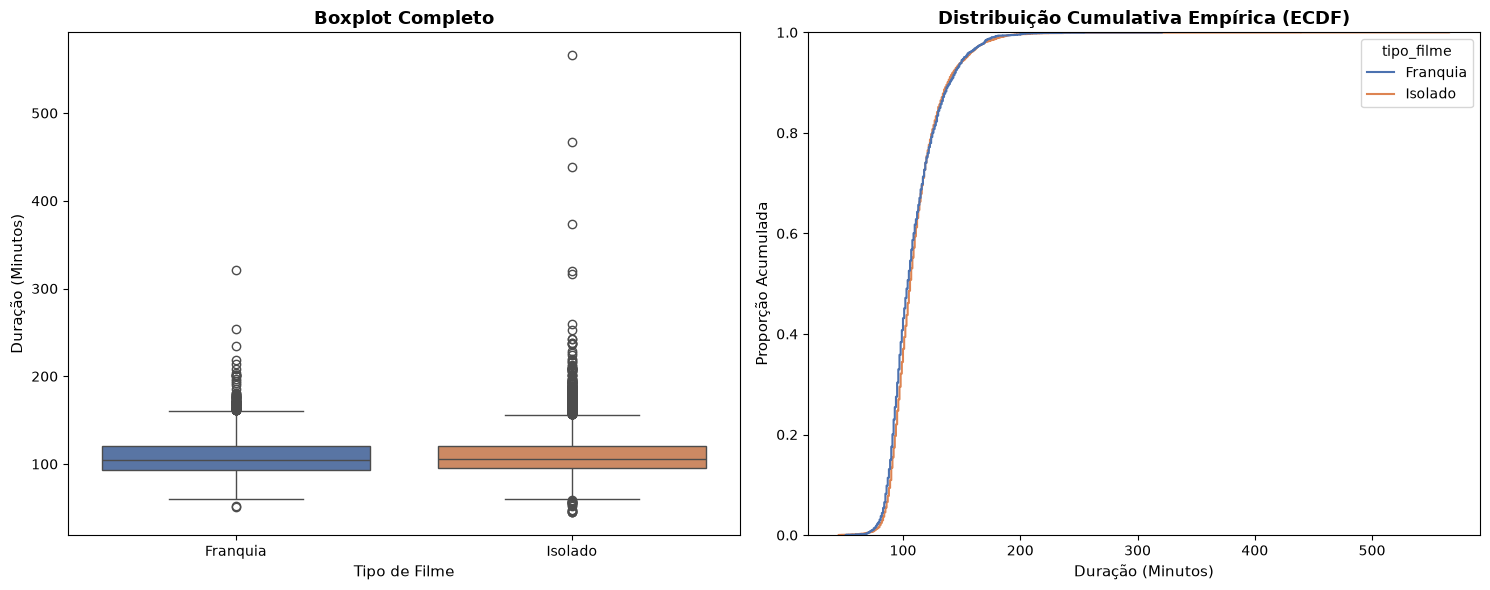

C:\Users\Danilo\AppData\Local\Temp\ipykernel_12308\3554707152.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


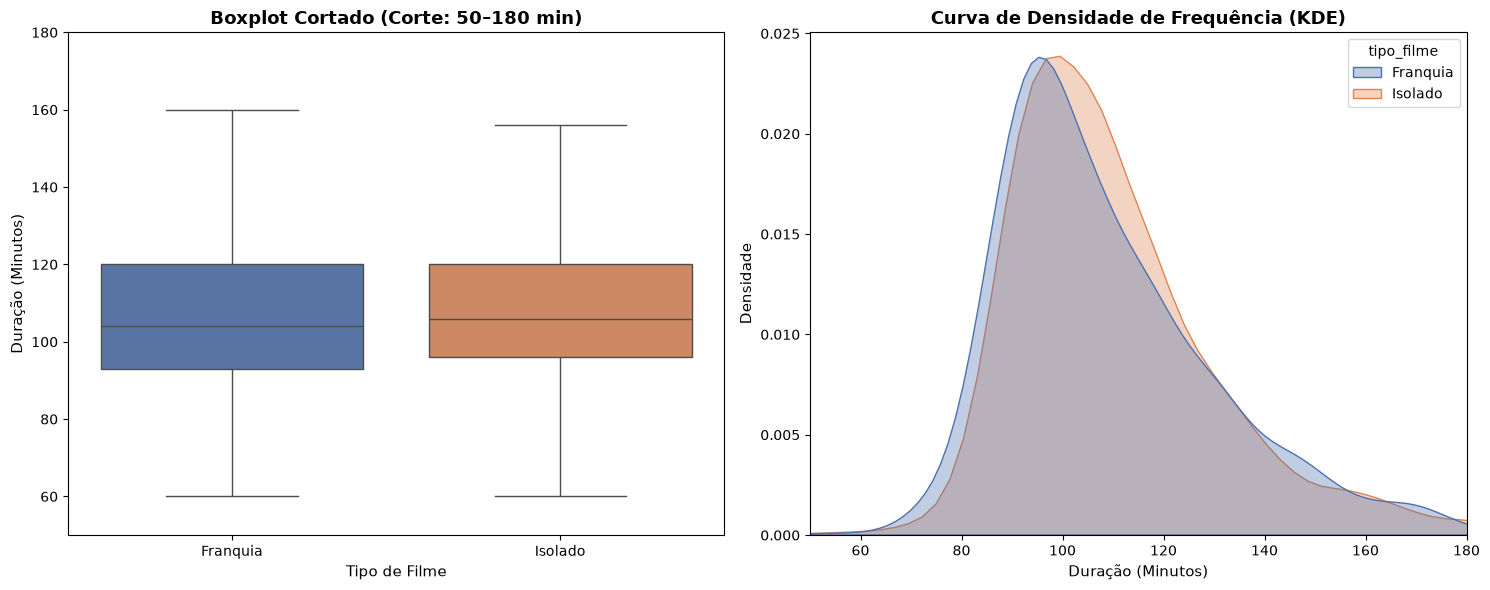

In [3]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Garantir criação da pasta de figuras
os.makedirs('../figs', exist_ok=True)

# =========================================================
# PAR 1: Visão Técnica e Rigorosa (Completo + ECDF)
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Boxplot Completo
sns.boxplot(
    data=df_valid,
    x='tipo_filme',
    y='runtimeMinutes',
    palette=['#4C72B0', '#DD8452'],
    ax=axes[0],
)
axes[0].set_title(
    'Boxplot Completo', fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Tipo de Filme', fontsize=11)
axes[0].set_ylabel('Duração (Minutos)', fontsize=11)

# 2. ECDF Plot
sns.ecdfplot(
    data=df_valid,
    x='runtimeMinutes',
    hue='tipo_filme',
    palette=['#4C72B0', '#DD8452'],
    ax=axes[1],
)
axes[1].set_title(
    'Distribuição Cumulativa Empírica (ECDF)', fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Duração (Minutos)', fontsize=11)
axes[1].set_ylabel('Proporção Acumulada', fontsize=11)

plt.tight_layout()
plt.savefig('../figs/h1_tecnico_completo.png', dpi=150)
plt.show()


# =========================================================
# PAR 2: Visão Intuitiva e Storytelling (Zoom + KDE)
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Boxplot com Zoom
sns.boxplot(
    data=df_valid,
    x='tipo_filme',
    y='runtimeMinutes',
    palette=['#4C72B0', '#DD8452'],
    ax=axes[0],
    showfliers=False,  # Oculta pontos atípicos
)
axes[0].set_title(
    'Boxplot Cortado (Corte: 50–180 min)', fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Tipo de Filme', fontsize=11)
axes[0].set_ylabel('Duração (Minutos)', fontsize=11)
axes[0].set_ylim(50, 180)

# 2. KDE Plot
sns.kdeplot(
    data=df_valid,
    x='runtimeMinutes',
    hue='tipo_filme',
    common_norm=False,
    fill=True,
    alpha=0.35,
    palette=['#4C72B0', '#DD8452'],
    ax=axes[1],
)
axes[1].set_title(
    'Curva de Densidade de Frequência (KDE)', fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Duração (Minutos)', fontsize=11)
axes[1].set_ylabel('Densidade', fontsize=11)
axes[1].set_xlim(50, 180)

plt.tight_layout()
plt.savefig('../figs/h1_intuitivo_zoom.png', dpi=150)
plt.show()

In [6]:
import os
import time
import pandas as pd
import requests
from dotenv import load_dotenv
from tqdm import tqdm

load_dotenv(dotenv_path='../.env')
TMDB_API_KEY = os.getenv('TMDB_API_KEY')
BASE_URL = 'https://api.themoviedb.org/3'

# 1. Carregar base e filtrar apenas franquias
df = pd.read_csv('../data/df_tmdb.csv')
franquias = df[df['is_franchise'] == True].copy()

# Estruturas para armazenar mapeamentos
tconst_to_tmdb = {}
tconst_to_collection = {}

print(f'Iniciando busca para {len(franquias)} filmes de franquia...')

# Passo 1: Mapear tconst -> tmdb_id -> collection_id (sem chamadas duplicadas)
for tconst in tqdm(franquias['tconst'], desc='Consultando Filmes no TMDB'):
  try:
    # Buscar tmdb_id
    res_find = requests.get(
        f'{BASE_URL}/find/{tconst}',
        params={'api_key': TMDB_API_KEY, 'external_source': 'imdb_id'},
        timeout=5,
    )
    if res_find.status_code == 200:
      results = res_find.json().get('movie_results', [])
      if results:
        tmdb_id = results[0]['id']
        tconst_to_tmdb[tconst] = tmdb_id

        # Buscar collection_id
        res_movie = requests.get(
            f'{BASE_URL}/movie/{tmdb_id}',
            params={'api_key': TMDB_API_KEY},
            timeout=5,
        )
        if res_movie.status_code == 200:
          collection = res_movie.json().get('belongs_to_collection')
          if collection:
            tconst_to_collection[tconst] = collection['id']
  except Exception:
    pass

  time.sleep(0.02)  # Respeita o limite de requisições da API

# Passo 2: Buscar detalhes de cada coleção única e determinar a ordem
collection_ids = set(tconst_to_collection.values())
collection_order = {}  # (tmdb_movie_id) -> posição na saga

for cid in tqdm(collection_ids, desc='Mapeando Ordem das Sagas'):
  try:
    res_coll = requests.get(
        f'{BASE_URL}/collection/{cid}',
        params={'api_key': TMDB_API_KEY},
        timeout=5,
    )
    if res_coll.status_code == 200:
      parts = res_coll.json().get('parts', [])
      parts_validas = [p for p in parts if p.get('release_date')]
      parts_ordenadas = sorted(parts_validas, key=lambda p: p['release_date'])

      for i, p in enumerate(parts_ordenadas, start=1):
        collection_order[p['id']] = i
  except Exception:
    pass

  time.sleep(0.02)

# Passo 3: Mapear a posição de volta para a base
franquias['saga_position'] = franquias['tconst'].map(
    lambda t: collection_order.get(tconst_to_tmdb[t])
    if t in tconst_to_tmdb
    else None
)

# Salvar o resultado final em disco
franquias.to_csv('../data/df_franquias_com_posicao.csv', index=False)
print('\nArquivo saved com sucesso em ../data/df_franquias_com_posicao.csv!')

Iniciando busca para 2605 filmes de franquia...


Mapeando Ordem das Sagas: 100%|██████████| 1396/1396 [18:21<00:00,  1.27it/s]


Arquivo saved com sucesso em ../data/df_franquias_com_posicao.csv!


C:\Users\Danilo\AppData\Local\Temp\ipykernel_17296\2315303563.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


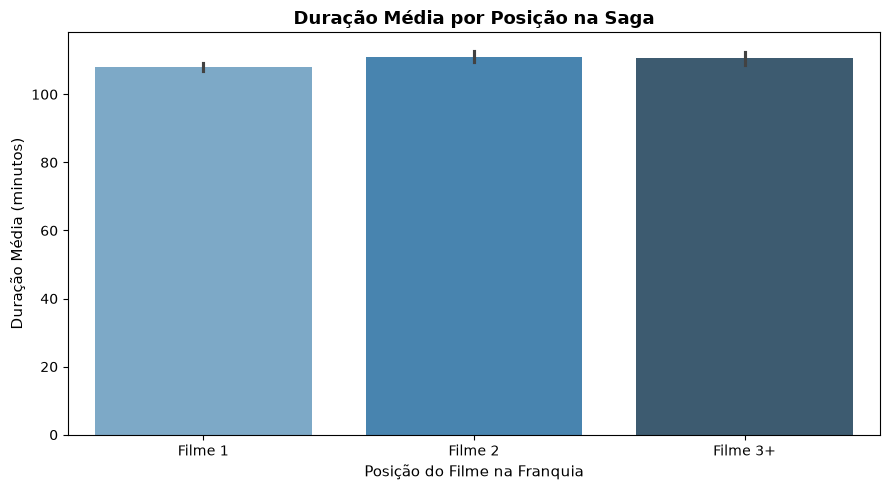

--- RESULTADOS DA REGRESSÃO LINEAR ---
Coeficiente Angular (Slope): 0.678 minutos por sequência lançada
Coeficiente de Determinação (R²): 0.0037
p-valor da Regressão: 1.84817e-03
Conclusão: Há significância estatística (p < 0.05) devido ao volume de dados, porém o impacto prático é irrisório (R² = 0.0037, ~41 segundos por sequência).


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

# Carregar dados processados das franquias
df_saga = pd.read_csv('../data/df_franquias_com_posicao.csv').dropna(
    subset=['saga_position', 'runtimeMinutes']
)
df_saga['saga_position'] = df_saga['saga_position'].astype(int)

# Agrupar para visualização em categorias
df_saga['grupo_saga'] = df_saga['saga_position'].apply(
    lambda x: 'Filme 1' if x == 1 else ('Filme 2' if x == 2 else 'Filme 3+')
)

# 1. Gráfico de Barras com Intervalo de Confiança
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_saga,
    x='grupo_saga',
    y='runtimeMinutes',
    order=['Filme 1', 'Filme 2', 'Filme 3+'],
    palette='Blues_d',
    errorbar=('ci', 95),
)
plt.title(
    'Duração Média por Posição na Saga', fontsize=13, fontweight='bold'
)
plt.xlabel('Posição do Filme na Franquia', fontsize=11)
plt.ylabel('Duração Média (minutos)', fontsize=11)
plt.tight_layout()
plt.savefig('../figs/h2_duracao_por_posicao_saga.png', dpi=150)
plt.show()

# 2. Regressão Linear (Requisito do Professor)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_saga['saga_position'], df_saga['runtimeMinutes']
)
r_squared = r_value**2

print('--- RESULTADOS DA REGRESSÃO LINEAR ---')
print(
    f'Coeficiente Angular (Slope): {slope:.3f} minutos por sequência lançada'
)
print(f'Coeficiente de Determinação (R²): {r_squared:.4f}')
print(f'p-valor da Regressão: {p_value:.5e}')

if p_value < 0.05 and r_squared > 0.05:
  print(
      "Conclusão: Há uma tendência estatisticamente e praticamente"
      " significativa de aumento na duração à medida que a saga progride."
  )
elif p_value < 0.05 and r_squared <= 0.05:
  print(
      "Conclusão: Há significância estatística (p < 0.05) devido ao volume de"
      f" dados, porém o impacto prático é irrisório (R² = {r_value**2:.4f},"
      f" ~{slope*60:.0f} segundos por sequência)."
  )
else:
  print(
      "Conclusão: Não há tendência linear significativa de alteração da"
      " duração conforme a saga avança."
  )


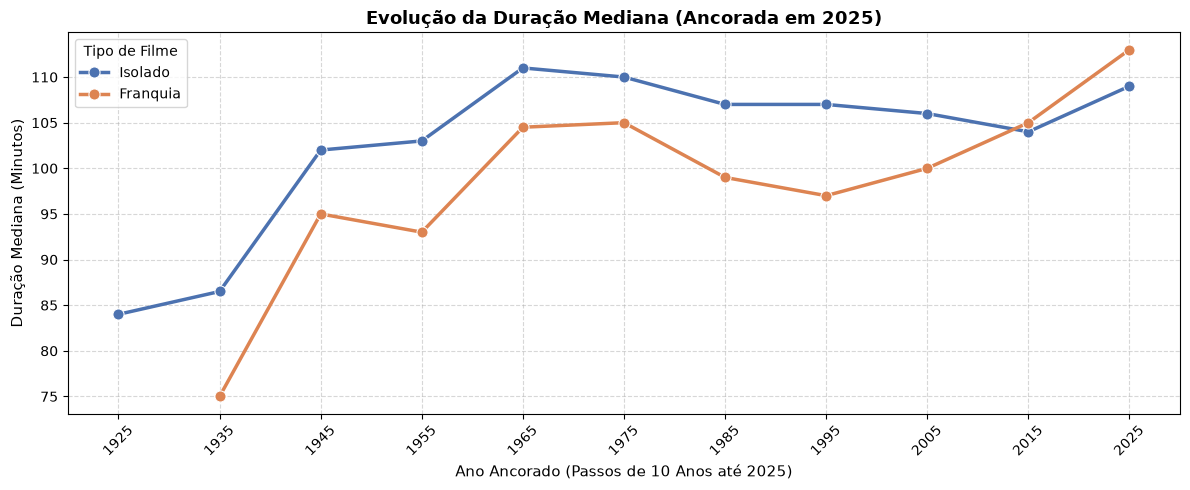

In [13]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Carregar e tratar os dados
df = pd.read_csv("../data/df_tmdb.csv")
df_clean = df.dropna(
    subset=["runtimeMinutes", "startYear", "is_franchise"]
).copy()

df_clean["startYear"] = df_clean["startYear"].astype(int)
df_clean["runtimeMinutes"] = df_clean["runtimeMinutes"].astype(int)
df_clean["tipo_filme"] = df_clean["is_franchise"].map(
    {True: "Franquia", False: "Isolado"}
)

# Filtrar filmes a partir de 1915 até 2025 para garantir que caibam nos bins
df_clean = df_clean[
    (df_clean["startYear"] > 1915) & (df_clean["startYear"] <= 2025)
].copy()

# 2. Criar intervalos de 10 anos terminando em 2025, 2015, 2005...
bins = list(range(1915, 2035, 10))  # [1915, 1925, ..., 2025, 2035]
labels = list(range(1925, 2035, 10))  # [1925, 1935, ..., 2025, 2035]

df_clean["ano_ancora"] = pd.cut(
    df_clean["startYear"], bins=bins, labels=labels, right=True
)

# Remove possíveis nulos de borda e converte com segurança para inteiro
df_clean = df_clean.dropna(subset=["ano_ancora"]).copy()
df_clean["ano_ancora"] = df_clean["ano_ancora"].astype(int)

# Garantir limite até 2025
df_clean = df_clean[df_clean["ano_ancora"] <= 2025]

# 3. Calcular a mediana agrupada por ano ancorado
mediana_ancorada = (
    df_clean.groupby(["ano_ancora", "tipo_filme"], observed=False)[
        "runtimeMinutes"
    ]
    .median()
    .reset_index()
)

# 4. Plotar o Gráfico de Linha
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=mediana_ancorada,
    x="ano_ancora",
    y="runtimeMinutes",
    hue="tipo_filme",
    marker="o",
    markersize=8,
    linewidth=2.5,
    palette=["#4C72B0", "#DD8452"],
)

plt.title(
    "Evolução da Duração Mediana (Ancorada em 2025)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Ano Ancorado (Passos de 10 Anos até 2025)", fontsize=11)
plt.ylabel("Duração Mediana (Minutos)", fontsize=11)

# Força o eixo X a exibir EXATAMENTE os anos ancorados (..., 1995, 2005, 2015, 2025)
anos_marcadores = sorted(mediana_ancorada["ano_ancora"].unique())
plt.xticks(anos_marcadores, rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Tipo de Filme")
plt.tight_layout()

os.makedirs("../figs", exist_ok=True)
plt.savefig("../figs/h3_evolucao_ancorada_2025.png", dpi=150)
plt.show()

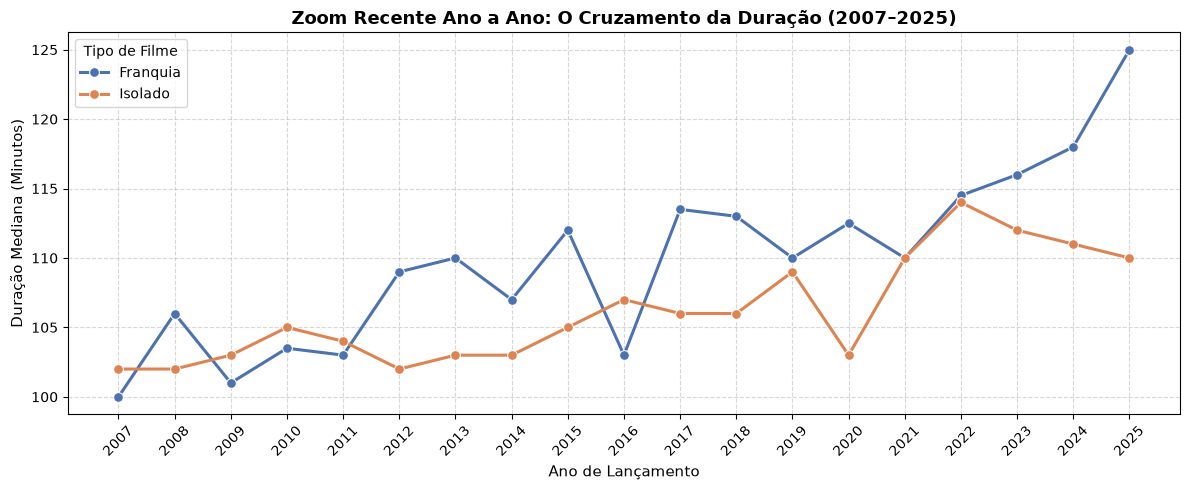

In [14]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Carregar e tratar os dados
df = pd.read_csv('../data/df_tmdb.csv')
df_clean = df.dropna(
    subset=['runtimeMinutes', 'startYear', 'is_franchise']
).copy()

df_clean['startYear'] = df_clean['startYear'].astype(int)
df_clean['runtimeMinutes'] = df_clean['runtimeMinutes'].astype(int)
df_clean['tipo_filme'] = df_clean['is_franchise'].map(
    {True: 'Franquia', False: 'Isolado'}
)

# 2. Calcular a mediana ano a ano
mediana_anual = (
    df_clean.groupby(['startYear', 'tipo_filme'], observed=False)[
        'runtimeMinutes'
    ]
    .median()
    .reset_index()
)

# Pivotar para encontrar o ano exato da virada pós-2000
pivot_anual = mediana_anual.pivot(
    index='startYear', columns='tipo_filme', values='runtimeMinutes'
)
piv_recent = pivot_anual.loc[2000:2025]

# Identifica o primeiro ano recente onde Franquias > Isolados
anos_virada = piv_recent[piv_recent['Franquia'] > piv_recent['Isolado']].index
ano_inicio = anos_virada[0] - 1 if len(anos_virada) > 0 else 2008

# Filtrar do ano anterior à virada até 2025
mediana_filtrada = mediana_anual[
    (mediana_anual['startYear'] >= ano_inicio)
    & (mediana_anual['startYear'] <= 2025)
]

# 3. Plotar o Gráfico de Linha (Ano a Ano)
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=mediana_filtrada,
    x='startYear',
    y='runtimeMinutes',
    hue='tipo_filme',
    marker='o',
    markersize=7,
    linewidth=2.2,
    palette=['#4C72B0', '#DD8452'],
)

plt.title(
    f'Zoom Recente Ano a Ano: O Cruzamento da Duração ({ano_inicio}–2025)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Ano de Lançamento', fontsize=11)
plt.ylabel('Duração Mediana (Minutos)', fontsize=11)

# Exibir todos os anos no eixo X individualmente
plt.xticks(range(ano_inicio, 2026), rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Tipo de Filme')
plt.tight_layout()

os.makedirs('../figs', exist_ok=True)
plt.savefig('../figs/h3_zoom_ano_a_ano.png', dpi=150)
plt.show()

In [15]:
# Lista os filmes de franquia de 2016 ordenados do menor para o maior runtime
f_2016 = df_clean[
    (df_clean['startYear'] == 2016) & (df_clean['is_franchise'] == True)
].sort_values('runtimeMinutes')

display(
    f_2016[['primaryTitle', 'runtimeMinutes']].head(15)
)  # Mostra os 15 mais curtos
print('Mediana em 2016:', f_2016['runtimeMinutes'].median())

,primaryTitle,runtimeMinutes
11262,The Thinning,81
10906,Terrifier,85
9856,The Secret Life of Pets,86
11401,Two Lottery Tickets,86
10863,Don't Breathe,88
8147,Blair Witch,89
9367,Leap!,89
11382,Alibi.com,89
10196,Kickboxer: Vengeance,90
8286,Norm of the North,90


Mediana em 2016: 103.0


In [16]:
import pandas as pd
from scipy import stats

# 1. Carregar dados das franquias com posição e dados gerais
df_main = pd.read_csv('../data/df_tmdb.csv')
df_saga = pd.read_csv('../data/df_franquias_com_posicao.csv')

# 2. Definir os grupos do Teste de Sensibilidade
# Grupo A: Apenas sequências (Filme 2, 3, 4...)
sequencias = df_saga[df_saga['saga_position'] >= 2]['runtimeMinutes'].dropna()

# Grupo B: Apenas isolados puros (que nunca viraram franquia)
isolados_puros = df_main[df_main['is_franchise'] == False][
    'runtimeMinutes'
].dropna()

# 3. Teste de Mann-Whitney U
u_stat, p_value = stats.mannwhitneyu(
    sequencias, isolados_puros, alternative='two-sided'
)
n1, n2 = len(sequencias), len(isolados_puros)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

# 4. Exibição dos Resultados
print(
    '=== ANÁLISE DE ROBUSTEZ (H1): SEQUÊNCIAS (FILME 2+) VS. ISOLADOS PUROS ==='
)
print(f'N Sequências (Filme 2+): {n1} | Mediana: {sequencias.median():.1f} min')
print(f'N Isolados Puros: {n2} | Mediana: {isolados_puros.median():.1f} min')
print(f'p-valor: {p_value:.5e}')
print(f'Tamanho do Efeito (Rank-Biserial r): {rank_biserial:.4f}')

if abs(rank_biserial) < 0.10:
  print(
      '\nConclusão da Robustez: Mesmo isolando apenas sequências puras (Filme'
      ' 2+), o efeito prático continua insignificante (r < 0.10). A'
      ' conclusão da H1 principal é mantida com alta estabilidade.'
  )
else:
  print(
      '\nConclusão da Robustez: O tamanho do efeito aumentou! A exclusão do'
      ' "Filme 1" revela que as sequências de fato possuem duração superior'
      ' em relação aos filmes isolados.'
  )

=== ANÁLISE DE ROBUSTEZ (H1): SEQUÊNCIAS (FILME 2+) VS. ISOLADOS PUROS ===
N Sequências (Filme 2+): 1251 | Mediana: 106.0 min
N Isolados Puros: 9850 | Mediana: 106.0 min
p-valor: 7.14632e-01
Tamanho do Efeito (Rank-Biserial r): 0.0063

Conclusão da Robustez: Mesmo isolando apenas sequências puras (Filme 2+), o efeito prático continua insignificante (r < 0.10). A conclusão da H1 principal é mantida com alta estabilidade.
